<a href="https://colab.research.google.com/github/sceylan058/paligemma2-resolution-test/blob/main/paligemma2_resolution_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Hücre 1: kurulum
!pip install -q -U transformers accelerate
from google.colab import userdata
from huggingface_hub import login
login(userdata.get("HF_TOKEN"))

from google.colab import files
uploaded = files.upload()        # a "Choose files" button appears: select images.zip
!unzip -o -q images.zip
!ls images

Saving images.zip to images (1).zip
img1_violence.png   img3_migration.png	img5_rnd_pie.png
img2_education.png  img4_rnd_table.png


In [9]:
from huggingface_hub import hf_hub_download
for m in ["google/paligemma2-3b-mix-224", "google/paligemma2-3b-mix-448"]:
    try:
        hf_hub_download(m, "config.json"); print(m, "-> access OK")
    except Exception as e:
        print(m, "-> NO access:", type(e).__name__)

google/paligemma2-3b-mix-224 -> access OK
google/paligemma2-3b-mix-448 -> access OK


In [10]:
import torch, time, gc, re
import pandas as pd
from PIL import Image
from transformers import PaliGemmaForConditionalGeneration, PaliGemmaProcessor

DTYPE = torch.bfloat16   # switch to torch.float32 if T4 raises an error

def load(model_id):
    model = PaliGemmaForConditionalGeneration.from_pretrained(
        model_id, torch_dtype=DTYPE, device_map="auto").eval()
    return model, PaliGemmaProcessor.from_pretrained(model_id)

def ask(model, processor, image, prompt, max_new_tokens=40):
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(DTYPE).to(model.device)
    n_in = inputs["input_ids"].shape[-1]
    torch.cuda.synchronize(); t0 = time.perf_counter()
    with torch.inference_mode():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    torch.cuda.synchronize(); dt = time.perf_counter() - t0
    return processor.decode(out[0][n_in:], skip_special_tokens=True).strip(), dt, n_in

def is_correct(answer, truths):
    a = answer.lower()
    for t in truths:
        if re.search(r"\d", t):   # numeric answer: compare digits only
            if re.sub(r"\D", "", t) in re.sub(r"\D", "", a): return True
        elif t.lower() in a: return True
    return False

In [11]:
IMG = "images/"
tests = [
  # (image, text_size, prompt, accepted_answers)
  ("img1_violence.png", "large", "answer en Which age group was most exposed to physical violence?", ["35-44"]),
  ("img1_violence.png", "large", "answer en What percentage of women aged 45-59 experienced physical violence?", ["14,3"]),
  ("img1_violence.png", "small", "answer en In the first chart, what percentage of women experienced economic violence?", ["18,3"]),
  ("img1_violence.png", "small", "answer en What percentage of women aged 15-24 experienced digital violence?", ["12,9"]),

  ("img2_education.png", "large", "answer en What was education spending per student in 2024 in TL?", ["100 307"]),
  ("img2_education.png", "large", "answer en What share of public education institutions' spending went to higher education?", ["33,4"]),
  ("img2_education.png", "small", "answer en What was total education spending in million US dollars in 2024?", ["66 979"]),
  ("img2_education.png", "small", "answer en What was the share of education spending in GDP in 2024?", ["4,9"]),

  ("img3_migration.png", "large", "answer en Which program did graduates who moved to Canada most often complete?", ["işletme", "isletme", "business"]),
  ("img3_migration.png", "large", "answer en Which program had the largest share among graduates who moved to the USA?", ["elektrik", "electric"]),
  ("img3_migration.png", "small", "answer en In the table, what is the second program listed for Germany?", ["makine", "mechanical"]),
  ("img3_migration.png", "small", "answer en In the table, what is the last program listed for the United Kingdom?", ["iktisat", "economics"]),

  ("img4_rnd_table.png", "large", "answer en By how much did R&D spending increase in 2024 compared to the previous year?", ["274"]),
  ("img4_rnd_table.png", "large", "answer en What was the share of R&D spending in GDP in 2024?", ["1,46"]),
  ("img4_rnd_table.png", "small", "answer en What was per capita R&D spending in TL in 2024?", ["7 354"]),
  ("img4_rnd_table.png", "small", "answer en According to the footnote, what was the purchasing power parity rate in 2024 (1 USD = ? TL)?", ["11,6"]),

  ("img5_rnd_pie.png", "large", "answer en What share of R&D spending was financed by companies?", ["53,8"]),
  ("img5_rnd_pie.png", "large", "answer en What share of R&D spending did higher education account for?", ["30,9"]),
  ("img5_rnd_pie.png", "small", "answer en In the expenditure group chart, what is the share of investment?", ["9,1"]),
  ("img5_rnd_pie.png", "small", "answer en In the expenditure group chart, what is the share of other current expenditures?", ["31,4"]),
]
print(len(tests), "questions")

20 questions


In [12]:
models = {"224": "google/paligemma2-3b-mix-224", "448": "google/paligemma2-3b-mix-448"}

rows = []
for res, model_id in models.items():
    model, processor = load(model_id)
    ask(model, processor, Image.open(IMG + tests[0][0]).convert("RGB"), "ocr")   # warm-up, not measured
    for img, size, prompt, truths in tests:
        ans, dt, n_in = ask(model, processor, Image.open(IMG + img).convert("RGB"), prompt)
        ok = is_correct(ans, truths)
        rows.append(dict(resolution=res, image=img, text_size=size, prompt=prompt,
                         ground_truth=" / ".join(truths), model_answer=ans,
                         correct=ok, seconds=round(dt, 2), input_tokens=n_in))
        print(res, size, "|", ans, "|", ok)
    del model; gc.collect(); torch.cuda.empty_cache()   # both models don't fit in memory at once

df = pd.DataFrame(rows)
df.to_csv("results.csv", index=False)

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many i

224 large | 12-19 | False


[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


224 large | 14.3 | True


...

448 large | 34% | False


[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


448 large | 4.4 | False


[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


448 small | 32.9 | False
448 small | 12.4 | False


In [13]:
   print(df.groupby(["resolution", "text_size"])["correct"].agg(["mean", "sum", "count"]))
print(df.groupby("resolution")[["seconds", "input_tokens"]].mean())

                      mean  sum  count
resolution text_size                  
224        large       0.1    1     10
           small       0.0    0     10
448        large       0.0    0     10
           small       0.2    2     10
            seconds  input_tokens
resolution                       
224           0.839        275.05
448           2.718       1043.05


In [15]:
pd.set_option("display.max_colwidth", 60)
df.pivot_table(index=["image", "text_size", "prompt"], columns="resolution",
               values="model_answer", aggfunc="first")

resolution                                                                                                   224  \
image              text_size prompt                                                                                
img1_violence.png  large     answer en What percentage of women aged 45-59 experienced...                   14.3   
                             answer en Which age group was most exposed to physical vi...                  12-19   
                   small     answer en In the first chart, what percentage of women ex...                   34.3   
                             answer en What percentage of women aged 15-24 experienced...                   30.5   
img2_education.png large     answer en What share of public education institutions' sp...                    21%   
                             answer en What was education spending per student in 2024...                  9,412   
                   small     answer en What was the share of education spending in GDP...                   2.2%   
                             answer en What was total education spending in million US...                  4,815   
img3_migration.png large     answer en Which program did graduates who moved to Canada...   undergraduate degree   
                             answer en Which program had the largest share among gradu...  undergraduate program   
                   small     answer en In the table, what is the last program listed f...      "Top of the pops"   
                             answer en In the table, what is the second program listed...                 darfur   
img4_rnd_table.png large     answer en By how much did R&D spending increase in 2024 c...           $7.1 billion   
                             answer en What was the share of R&D spending in GDP in 2024?                   2.2%   
                   small     answer en According to the footnote, what was the purchas...                   1.82   
                             answer en What was per capita R&D spending in TL in 2024?                      1.46   
img5_rnd_pie.png   large     answer en What share of R&D spending did higher education...                    21%   
                             answer en What share of R&D spending was financed by comp...                    53%   
                   small     answer en In the expenditure group chart, what is the sha...                  56.3%   
                             answer en In the expenditure group chart, what is the sha...                  22.7%   

resolution                                                                                                               448  
image              text_size prompt                                                                                           
img1_violence.png  large     answer en What percentage of women aged 45-59 experienced...                               12.8  
                             answer en Which age group was most exposed to physical vi...                              18-24  
                   small     answer en In the first chart, what percentage of women ex...                               18.3  
                             answer en What percentage of women aged 15-24 experienced...                               12.8  
img2_education.png large     answer en What share of public education institutions' sp...                                11%  
                             answer en What was education spending per student in 2024...                                307  
                   small     answer en What was the share of education spending in GDP...                                4.9  
                             answer en What was total education spending in million US...                              3,052  
img3_migration.png large     answer en Which program did graduates who moved to Canada...                  bachelor's degree  
                             answer en Which progr

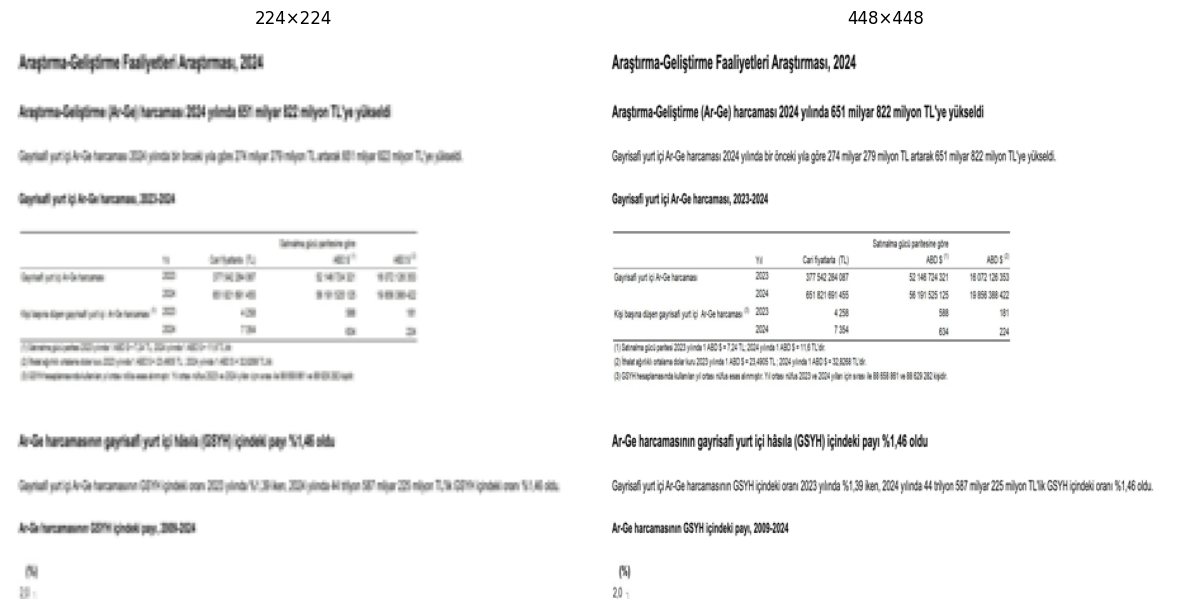

In [17]:
import matplotlib.pyplot as plt
im = Image.open(IMG + "img4_rnd_table.png").convert("RGB")
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for a, s in zip(ax, [224, 448]):
    a.imshow(im.resize((s, s), Image.BICUBIC)); a.set_title(f"{s}×{s}"); a.axis("off")
plt.tight_layout(); plt.savefig("model_view.png", dpi=150)

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

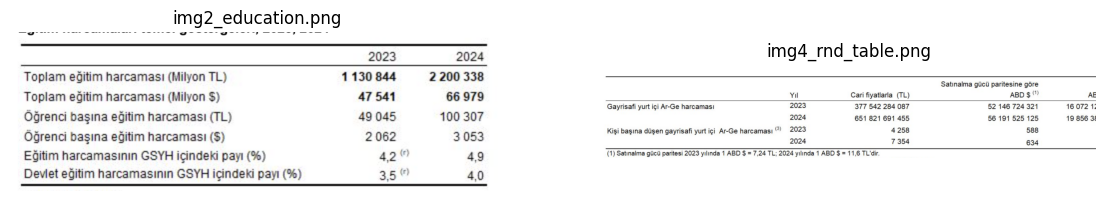

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


img2_education.png | What was total education spending in million US do | 3,053 | truth: ['66 979']


[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


img2_education.png | What was the share of education spending in GDP in | 4.9 | truth: ['4,9']


[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


img4_rnd_table.png | What was per capita R&D spending in TL in 2024? | 7,354 | truth: ['7 354']
img4_rnd_table.png | According to the footnote, what was the purchasing | 1.6 | truth: ['11,6']


In [20]:
model, processor = load("google/paligemma2-3b-mix-448")

crops = {  # (left, top, right, bottom) in original pixels: the table area only
  "img2_education.png": (40, 60, 1030, 380),
  "img4_rnd_table.png": (30, 380, 1600, 680),
}

# first, check that the crops look right
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, len(crops), figsize=(14, 4))
for a, (img, box) in zip(ax, crops.items()):
    a.imshow(Image.open(IMG + img).convert("RGB").crop(box)); a.set_title(img); a.axis("off")
plt.show()

for img, box in crops.items():
    im = Image.open(IMG + img).convert("RGB").crop(box)
    for _, size, prompt, truths in [t for t in tests if t[0] == img and t[1] == "small"]:
        ans = ask(model, processor, im, prompt)[0]
        print(img, "|", prompt[10:60], "|", ans, "| truth:", truths)